# GET-Pak workflow tutorial to process a single L2B image 

Here we expand the lower-level steps used inside `getpak.automation.Pipelines` for one matched GRS image and WaterDetect mask using the paths declared in `example_settings.ini`.

## INDEX

[1. Resolve the repository path](#1.-Resolve-the-repository-path)  
[2. Import lower level GET-Pak functions](#2.-Import-lower-level-GET-Pak-functions)  
[3. Read local settings.ini](#3.-Read-local-settings)  
[4. Discover GRS and WaterDetect date matchups](#4.-Discover-GRS-and-WaterDetect-date-matchups)  
[5. Select one image mask pair](#5.-Select-one-image-mask-pair)  
[6. Load Rrs data and apply the water mask](#6.-Load-Rrs-data-and-apply-the-water-mask)  
[7. Filter bad pixels and extract Rrs bands](#7.-Filter-bad-pixels-and-extract-Rrs-bands)  
[8. Classify OWTs and compute L2B products](#8.-Classify-OWTs-and-compute-L2B-products)  
[9. Quick visual check](#9.-Quick-visual-check)  
[10. Write GeoTIFF outputs for scene](#10.-Optional:-write-GeoTIFF-outputs-for-this-one-scene)  


## 1. Resolve the repository path

The notebook can be opened from the repository root or from the `examples/` folder. This cell makes local `getpak` imports work in both cases.

In [1]:
import os
import sys
import json
import math
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.colors import BoundaryNorm

In [2]:
Path.cwd()

PosixPath('/media/guimaraes/T7/git_t7/get-pak/examples')

In [3]:
# Path to your GET-Pak folder
REPO_ROOT = Path('/media/guimaraes/T7/git_t7/get-pak/')

In [4]:
if not (REPO_ROOT / "getpak").exists():
    REPO_ROOT = REPO_ROOT.parent

if not (REPO_ROOT / "getpak").exists():
    raise RuntimeError("Could not find the GET-Pak repository root.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

PosixPath('/media/guimaraes/T7/git_t7/get-pak')

[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 2. Import lower-level GET-Pak functions

`automation.py` creates instances of these classes internally. Here they are imported directly so each processing step is visible.

In [5]:
%%time
from getpak.input import Input, GRS, get_input_nc
from getpak.methods import Methods
from getpak.output import Raster
from getpak.commons import Utils

input_reader = Input()
grs_reader = GRS()
methods = Methods()

CPU times: user 268 ms, sys: 69.7 ms, total: 338 ms
Wall time: 343 ms


In [20]:
Utils.print_logo()


            _..._
          .'     '.      _
         /    .-""-\   _/ \ 
       .-|   /:.   |  |   | 
       |  \  |:.   /.-'-./ 
       | .-'-;:__.'    =/  ,ad8888ba,  88888888888 888888888888                          88
       .'=  *=|CNES _.='  d8"'    `"8b 88               88                               88
      /   _.  |    ;     d8'           88               88                               88
     ;-.-'|    \   |     88            88aaaaa          88        8b,dPPYba,  ,adPPYYba, 88   ,d8
    /   | \    _\  _\    88      88888 88"""""          88 aaaaaa 88P'    "8a ""     `Y8 88 ,a8"
    \__/'._;.  ==' ==\   Y8,        88 88               88 """""" 88       d8 ,adPPPPP88 8888[
    /|\  /|\ \    \   |   Y8a.    .a88 88               88        88b,   ,a8" 88,    ,88 88`"Yba,
   / | \/ | \/    /   /    `"Y88888P"  88888888888      88        88`YbbdP"'  `"8bbdP"Y8 88   `Y8a
  /  | || |  /-._/-._/                                            88
             \   `\  \              

[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 3. Read local settings

`example_settings.ini` is used here because it points to the local example GRS files, WaterDetect masks, output folder, and ROI vectors.

In [6]:
%%time
CONFIG_PATH = REPO_ROOT / "examples" / "example_settings.ini"
settings = Utils.read_config(config_path=str(CONFIG_PATH))

input_folder = Path(settings.get("client_folder", "inputs")["inputs"])
output_folder = Path(settings.get("client_folder", "output")["output"])
wmask_folder = Path(settings.get("client_folder", "wmask_folder")["wmask_folder"])
roi_vectors = settings["roi_vectors"]

tile_id = settings.get("processing", "s2_tile")["s2_tile"]
grs_version = settings.get("processing", "grs_version")["grs_version"]
report_rrs = str(settings.get("processing", "report_rrs")["report_rrs"]).lower() == "true"

print(f"GRS input root: {input_folder}")
print(f"Tile input folder: {input_folder / tile_id}")
print(f"Water mask folder: {wmask_folder}")
print(f"Output folder: {output_folder}")
print(f"Tile: {tile_id}")
print(f"GRS version: {grs_version}")
print(f"Report Rrs bands: {report_rrs}")

Atempting to read config file: /media/guimaraes/T7/git_t7/get-pak/examples/example_settings.ini
Done.
GRS input root: /media/guimaraes/T7/gpk_test_files/GRS_from_datalake
Tile input folder: /media/guimaraes/T7/gpk_test_files/GRS_from_datalake/50RKU
Water mask folder: /media/guimaraes/T7/gpk_test_files/50RKU_water_masks
Output folder: /media/guimaraes/T7/gpk_test_files/GPK_out
Tile: 50RKU
GRS version: v20
Report Rrs bands: True
CPU times: user 0 ns, sys: 819 μs, total: 819 μs
Wall time: 750 μs


[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 4. Discover GRS and WaterDetect date matchups

This reproduces the matching logic from `Pipelines.get_matchups()` without starting the full pipeline. <br>
Mind that a successfull matchup will only occur if: <br>
- The water masks contain the same date fo the satellite image counterpart;
- Their names ends with water_mask.tif; <br>

If that is not the case, check the logic inside `Methods.get_waterdetect_masks()` for more information.

In [7]:
%%time
tile_input_folder = input_folder / tile_id

grs_file_list = Utils.walktalk(str(tile_input_folder), unwanted_string="*_anc*")

grs_dates = []
meta_by_date = {}
for grs_file in grs_file_list:
    info = GRS.metadata(grs_file)
    date = info["year"] + info["month"] + info["day"]
    grs_dates.append(date)
    meta_by_date[date] = info

wd_dates, wd_masks_list = methods.get_waterdetect_masks(input_folder=str(wmask_folder))

matches, str_matches, dates = methods.sch_date_matchups(
    fst_dates=grs_dates,
    snd_dates=wd_dates,
    fst_tile_list=grs_file_list,
    snd_tile_list=wd_masks_list,
)

print(f"GRS files found: {len(grs_file_list)}")
print(f"WaterDetect masks found: {len(wd_masks_list)}")
print(f"Date matchups found: {len(str_matches)}")
list(str_matches)[:5]

10 files found.
Found 447 water masks in /media/guimaraes/T7/gpk_test_files/50RKU_water_masks

Found 10 match-ups

GRS files found: 10
WaterDetect masks found: 447
Date matchups found: 7
CPU times: user 6.5 ms, sys: 101 ms, total: 108 ms
Wall time: 107 ms


['20230711', '20230728', '20230728_2', '20230628', '20230628_2']

In [8]:
str_matches

{'20230711': {'IMG': '/media/guimaraes/T7/gpk_test_files/GRS_from_datalake/50RKU/07/11/S2B_MSIL2Agrs_20230711T030529_N0509_R075_T50RKU_20230711T045815/S2B_MSIL2Agrs_20230711T030529_N0509_R075_T50RKU_20230711T045815.nc',
  'WM': '/media/guimaraes/T7/gpk_test_files/50RKU_water_masks/SENTINEL2B_20230711-031934-412_L2A_T50RKU_C_V3-1_water_mask.tif'},
 '20230728': {'IMG': '/media/guimaraes/T7/gpk_test_files/GRS_from_datalake/50RKU/07/28/S2B_MSIL2Agrs_20230728T025529_N0509_R032_T50RKU_20230728T044758/S2B_MSIL2Agrs_20230728T025529_N0509_R032_T50RKU_20230728T044758.nc',
  'WM': '/media/guimaraes/T7/gpk_test_files/50RKU_water_masks/SENTINEL2B_20230728-030941-092_L2A_T50RKU_C_V3-1_water_mask.tif'},
 '20230728_2': {'IMG': '/media/guimaraes/T7/gpk_test_files/GRS_from_datalake/50RKU/07/28/S2B_MSIL2Agrs_20230728T025529_N0510_R032_T50RKU_20241019T044847/S2B_MSIL2Agrs_20230728T025529_N0510_R032_T50RKU_20241019T044847.nc',
  'WM': '/media/guimaraes/T7/gpk_test_files/50RKU_water_masks/SENTINEL2B_2023072

[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 5. Select one image-mask pair

Change `SCENE_INDEX` to process a different matched scene. The rest of the notebook processes only this selected key.

In [9]:
SCENE_INDEX = 3

In [10]:
%%time
matched_keys = list(str_matches.keys())
if not matched_keys:
    raise RuntimeError("No GRS/WaterDetect date matchups were found.")

scene_key = matched_keys[SCENE_INDEX]
image_path = str_matches[scene_key]["IMG"]
water_mask_path = str_matches[scene_key]["WM"]

print(f"Selected scene key: {scene_key}")
print(f"GRS image: {image_path}")
print(f"Water mask: {water_mask_path}")
meta_by_date.get(scene_key, {})

Selected scene key: 20230628
GRS image: /media/guimaraes/T7/gpk_test_files/GRS_from_datalake/50RKU/06/28/S2B_MSIL2Agrs_20230628T025529_N0509_R032_T50RKU_20230628T044811/S2B_MSIL2Agrs_20230628T025529_N0509_R032_T50RKU_20230628T044811.nc
Water mask: /media/guimaraes/T7/gpk_test_files/50RKU_water_masks/SENTINEL2B_20230628-030940-661_L2A_T50RKU_C_V3-1_water_mask.tif
CPU times: user 80 μs, sys: 21 μs, total: 101 μs
Wall time: 94.2 μs


{'input_file': PosixPath('/media/guimaraes/T7/gpk_test_files/GRS_from_datalake/50RKU/06/28/S2B_MSIL2Agrs_20230628T025529_N0509_R032_T50RKU_20230628T053359/S2B_MSIL2Agrs_20230628T025529_N0509_R032_T50RKU_20230628T053359.nc'),
 'basename': 'S2B_MSIL2Agrs_20230628T025529_N0509_R032_T50RKU_20230628T053359.nc',
 'mission': 'S2B',
 'prod_lvl': 'MSIL2Agrs',
 'str_date': '20230628',
 'pydate': datetime.datetime(2023, 6, 28, 2, 55, 29),
 'year': '2023',
 'month': '06',
 'day': '28',
 'baseline_algo_version': 'N0509',
 'relative_orbit': 'R032',
 'tile': 'T50RKU',
 'product_discriminator': '20230628T053359',
 'cloud_cover': 'NA',
 'grs_ver': 'NA'}

[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 6. Load Rrs data and apply the water mask

This corresponds to the `Loading GRS data` and `Intersecting image with water mask` block in `Pipelines.matchups_to_l2b()`.

In [11]:
%%time
grs_raw = input_reader.get_input_nc(
    file=image_path,
    sensor="S2MSI",
    AC_processor="GRS",
    grs_version=grs_version,
)

grs = methods.intersect_watermask(
    rrs_dict=grs_raw,
    water_mask_dir=water_mask_path,
)

print(grs)

Done.
<xarray.Dataset>
Dimensions:      (y: 5490, x: 5490)
Coordinates:
  * y            (y) float64 3.4e+06 3.4e+06 3.4e+06 ... 3.29e+06 3.29e+06
  * x            (x) float64 2e+05 2e+05 2e+05 ... 3.097e+05 3.098e+05 3.098e+05
    spatial_ref  int64 0
    band         int64 1
Data variables:
    Aerosol      (y, x) float32 dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    Blue         (y, x) float32 dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    Green        (y, x) float32 dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    Red          (y, x) float32 dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    RedEdge1     (y, x) float32 dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    RedEdge2     (y, x) float32 dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    RedEdge3     (y, x) float32 dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    Nir1         (y, x) float32 dask.array<chunksize=(5490, 5490), meta=np.ndarray>
    Nir2         (y, x) float32 da

[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 7. Filter bad pixels and extract Rrs bands

The pixel counters are kept in the same form used by `automation.py` before writing `npixels_*.txt`.

In [12]:
%%time
pixels = np.array([
    ["Water_pixels", "0"],
    ["Neg_Rrs_B4", "0"],
    ["Low_Rrs", "0"],
    ["OWT_1", "0"],
], dtype=object)

grs = methods.filter_pixels(
    rrs_dict=grs,
    neg_rrs="Red",
    low_rrs=True,
    low_rrs_thresh=0.002,
    low_rrs_bands=["Aerosol", "Blue", "Green", "Red", "RedEdge1", "RedEdge2"],
)

pixels[0, 1] = methods.npix
pixels[1, 1] = methods.negpix
pixels[2, 1] = methods.lowrrs

rrs_bands = {
    "Aerosol": methods._quick_rrs(rrs_dict=grs, bname="Aerosol"),
    "Blue": methods._quick_rrs(rrs_dict=grs, bname="Blue"),
    "Green": methods._quick_rrs(rrs_dict=grs, bname="Green"),
    "Red": methods._quick_rrs(rrs_dict=grs, bname="Red"),
    "RedEdge1": methods._quick_rrs(rrs_dict=grs, bname="RedEdge1"),
    "RedEdge2": methods._quick_rrs(rrs_dict=grs, bname="RedEdge2"),
    "RedEdge3": methods._quick_rrs(rrs_dict=grs, bname="RedEdge3"),
    "Nir2": methods._quick_rrs(rrs_dict=grs, bname="Nir2"),
}

pixels

/home/guimaraes/anaconda3/envs/gpk310/lib/python3.10/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


CPU times: user 13.5 s, sys: 10.7 s, total: 24.2 s
Wall time: 11.3 s


array([['Water_pixels', 313238],
       ['Neg_Rrs_B4', 25066],
       ['Low_Rrs', 2],
       ['OWT_1', '0']], dtype=object)

[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 8. Classify OWTs and compute L2B products

This is the core per-image logic from `matchups_to_l2b()`: classify optical water types, compute OWT weights, then calculate Chla, turbidity, and Hybrid-SPM.

In [13]:
%%time
class_px, angles = methods.classify_owt_chla_px(rrs_dict=grs, sensor="S2MSI", B1=True)

if class_px.sum() <= 0:
    raise RuntimeError("No valid pixels were found for this image after filtering.")

owt_classes, owt_weights = methods.classify_owt_chla_weights(
    class_px=class_px,
    angles=angles,
    n=3,
)

classes_turb, angles_turb = methods.classify_owt_spm_px(
    rrs_dict=grs,
    sensor="S2MSI",
    B1=True,
)

low_rrs_bands = ["Aerosol", "Blue", "Green", "Red", "RedEdge1", "RedEdge2"]
stacked = xr.concat([grs[var] for var in low_rrs_bands], dim="variable")
max_values = stacked.max(dim="variable")
owt14_mask = max_values < 0.005

if np.where(owt14_mask.values)[0].size > 0:
    owt_classes[0, owt14_mask] = 14
    owt_classes[1, owt14_mask] = 0
    owt_classes[2, owt14_mask] = 0
    owt_weights[0, owt14_mask] = 1
    owt_weights[1, owt14_mask] = 0
    owt_weights[2, owt14_mask] = 0

pixels[3, 1] = np.count_nonzero(owt_classes[0, :, :] == 1)

chla = methods.blended_chla(
    rrs_dict=grs,
    owt_classes=owt_classes,
    owt_weights=owt_weights,
    limits=True,
)

turb = methods.turb(
    rrs_dict=grs,
    class_owt_spt=classes_turb,
    alg="owt",
    limits=True,
)

hyspm = methods.turb(
    rrs_dict=grs,
    class_owt_spt=classes_turb,
    alg="Hybrid",
    limits=True,
)

chla[np.where(owt_classes[0, :, :] == 1)] = 0
turb[np.where(owt_classes[0, :, :] == 1)] = 0
hyspm[np.where(owt_classes[0, :, :] == 1)] = 0

print("Pixel counters")
print(pixels)
print("Output arrays")
print(f"OWT: {owt_classes[0].shape}, Chla: {chla.shape}, Turb: {turb.shape}, HySPM: {hyspm.shape}")

/media/guimaraes/T7/git_t7/get-pak/getpak/inversion_functions.py:45: RuntimeWarning: invalid value encountered in power
  chl = ((RedEdge1 / Red) * (aw708 + bb) - aw665 - bb ** a) / b
/media/guimaraes/T7/git_t7/get-pak/getpak/inversion_functions.py:20: RuntimeWarning: invalid value encountered in power
  chl = (0.7864 * (RedEdge1 / Red) / a - 0.4245 / a) ** b
/media/guimaraes/T7/git_t7/get-pak/getpak/inversion_functions.py:82: RuntimeWarning: invalid value encountered in log10
  X = np.log10(Blue / Green)
/media/guimaraes/T7/git_t7/get-pak/getpak/inversion_functions.py:83: RuntimeWarning: overflow encountered in power
  chl = 10 ** (a + b * X + c * X ** 2 + d * X ** 3 + e * X ** 4)
/media/guimaraes/T7/git_t7/get-pak/getpak/methods.py:682: RuntimeWarning: overflow encountered in cast
  chla[index] = ifunc.chl_OC2(Blue=rrs_dict['Blue'].values[index],
/media/guimaraes/T7/git_t7/get-pak/getpak/inversion_functions.py:82: RuntimeWarning: invalid value encountered in log10
  X = np.log10(Blue

Pixel counters
[['Water_pixels' 313238]
 ['Neg_Rrs_B4' 25066]
 ['Low_Rrs' 2]
 ['OWT_1' 23861]]
Output arrays
OWT: (5490, 5490), Chla: (5490, 5490), Turb: (5490, 5490), HySPM: (5490, 5490)
CPU times: user 2min 22s, sys: 1min 34s, total: 3min 56s
Wall time: 1min 42s


[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 9. Quick visual check
These plots are for inspection only. They are not part of the automated pipeline.

- using nearest-neighbour display so sparse pixels are not visually smoothed away,
- cropping to the valid-data footprint with padding,
- masking zero/NaN background values, and
- using percentile contrast for continuous products.

In [14]:
# ---- Display controls ---------------------------------------------------------
# If small valid pixels disappear in the full 5490 x 5490 scene, keep this True.
# It crops the plot to the valid-data footprint and leaves padding around it.
ZOOM_TO_VALID_DATA = True
CROP_PADDING_PIXELS = 120

# Increase these if the notebook display still feels too small.
MAX_COLS = 3
PANEL_WIDTH = 6.2
PANEL_HEIGHT = 5.4
DPI = 180

# In these products, 0 is normally used as no-data/background in the quick check.
# Set to False if you explicitly want to see zero-valued product pixels.
HIDE_ZERO_BACKGROUND = True

# Optional high-resolution export.
SAVE_FIGURE = False
FIGURE_PATH = "quick_visual_check.png"

plot_items = [
    (owt_classes[0], "Dominant OWT", "discrete"),
    (classes_turb, "SPM OWT", "discrete"),
    (chla, "Chla", "continuous"),
    (turb, "Turbidity", "continuous"),
    (hyspm, "Hybrid-SPM", "continuous"),
    (rrs_bands["Red"], "Rrs Red", "continuous"),
    (rrs_bands["Nir2"], "Rrs Nir2", "continuous"),
]

In [15]:
def as_float_array(array):
    """Return a plain NumPy float array from NumPy/xarray-like inputs."""
    if hasattr(array, "values"):
        array = array.values
    return np.asarray(array, dtype="float64")


def valid_data_mask(array):
    """Mask used to find and display the meaningful data footprint."""
    arr = as_float_array(array)
    mask = np.isfinite(arr)
    if HIDE_ZERO_BACKGROUND:
        mask &= arr != 0
    return mask


def crop_slices_from_items(items, padding):
    """Return row/column slices covering valid pixels across all plotted arrays."""
    first = as_float_array(items[0][0])
    combined = np.zeros(first.shape, dtype=bool)

    for array, _, _ in items:
        arr = as_float_array(array)
        if arr.shape != first.shape:
            raise ValueError(f"All arrays must have the same shape. Found {arr.shape} and {first.shape}.")
        combined |= valid_data_mask(arr)

    if not combined.any():
        return slice(0, first.shape[0]), slice(0, first.shape[1])

    rows, cols = np.where(combined)
    row_slice = slice(max(rows.min() - padding, 0), min(rows.max() + padding + 1, first.shape[0]))
    col_slice = slice(max(cols.min() - padding, 0), min(cols.max() + padding + 1, first.shape[1]))
    return row_slice, col_slice

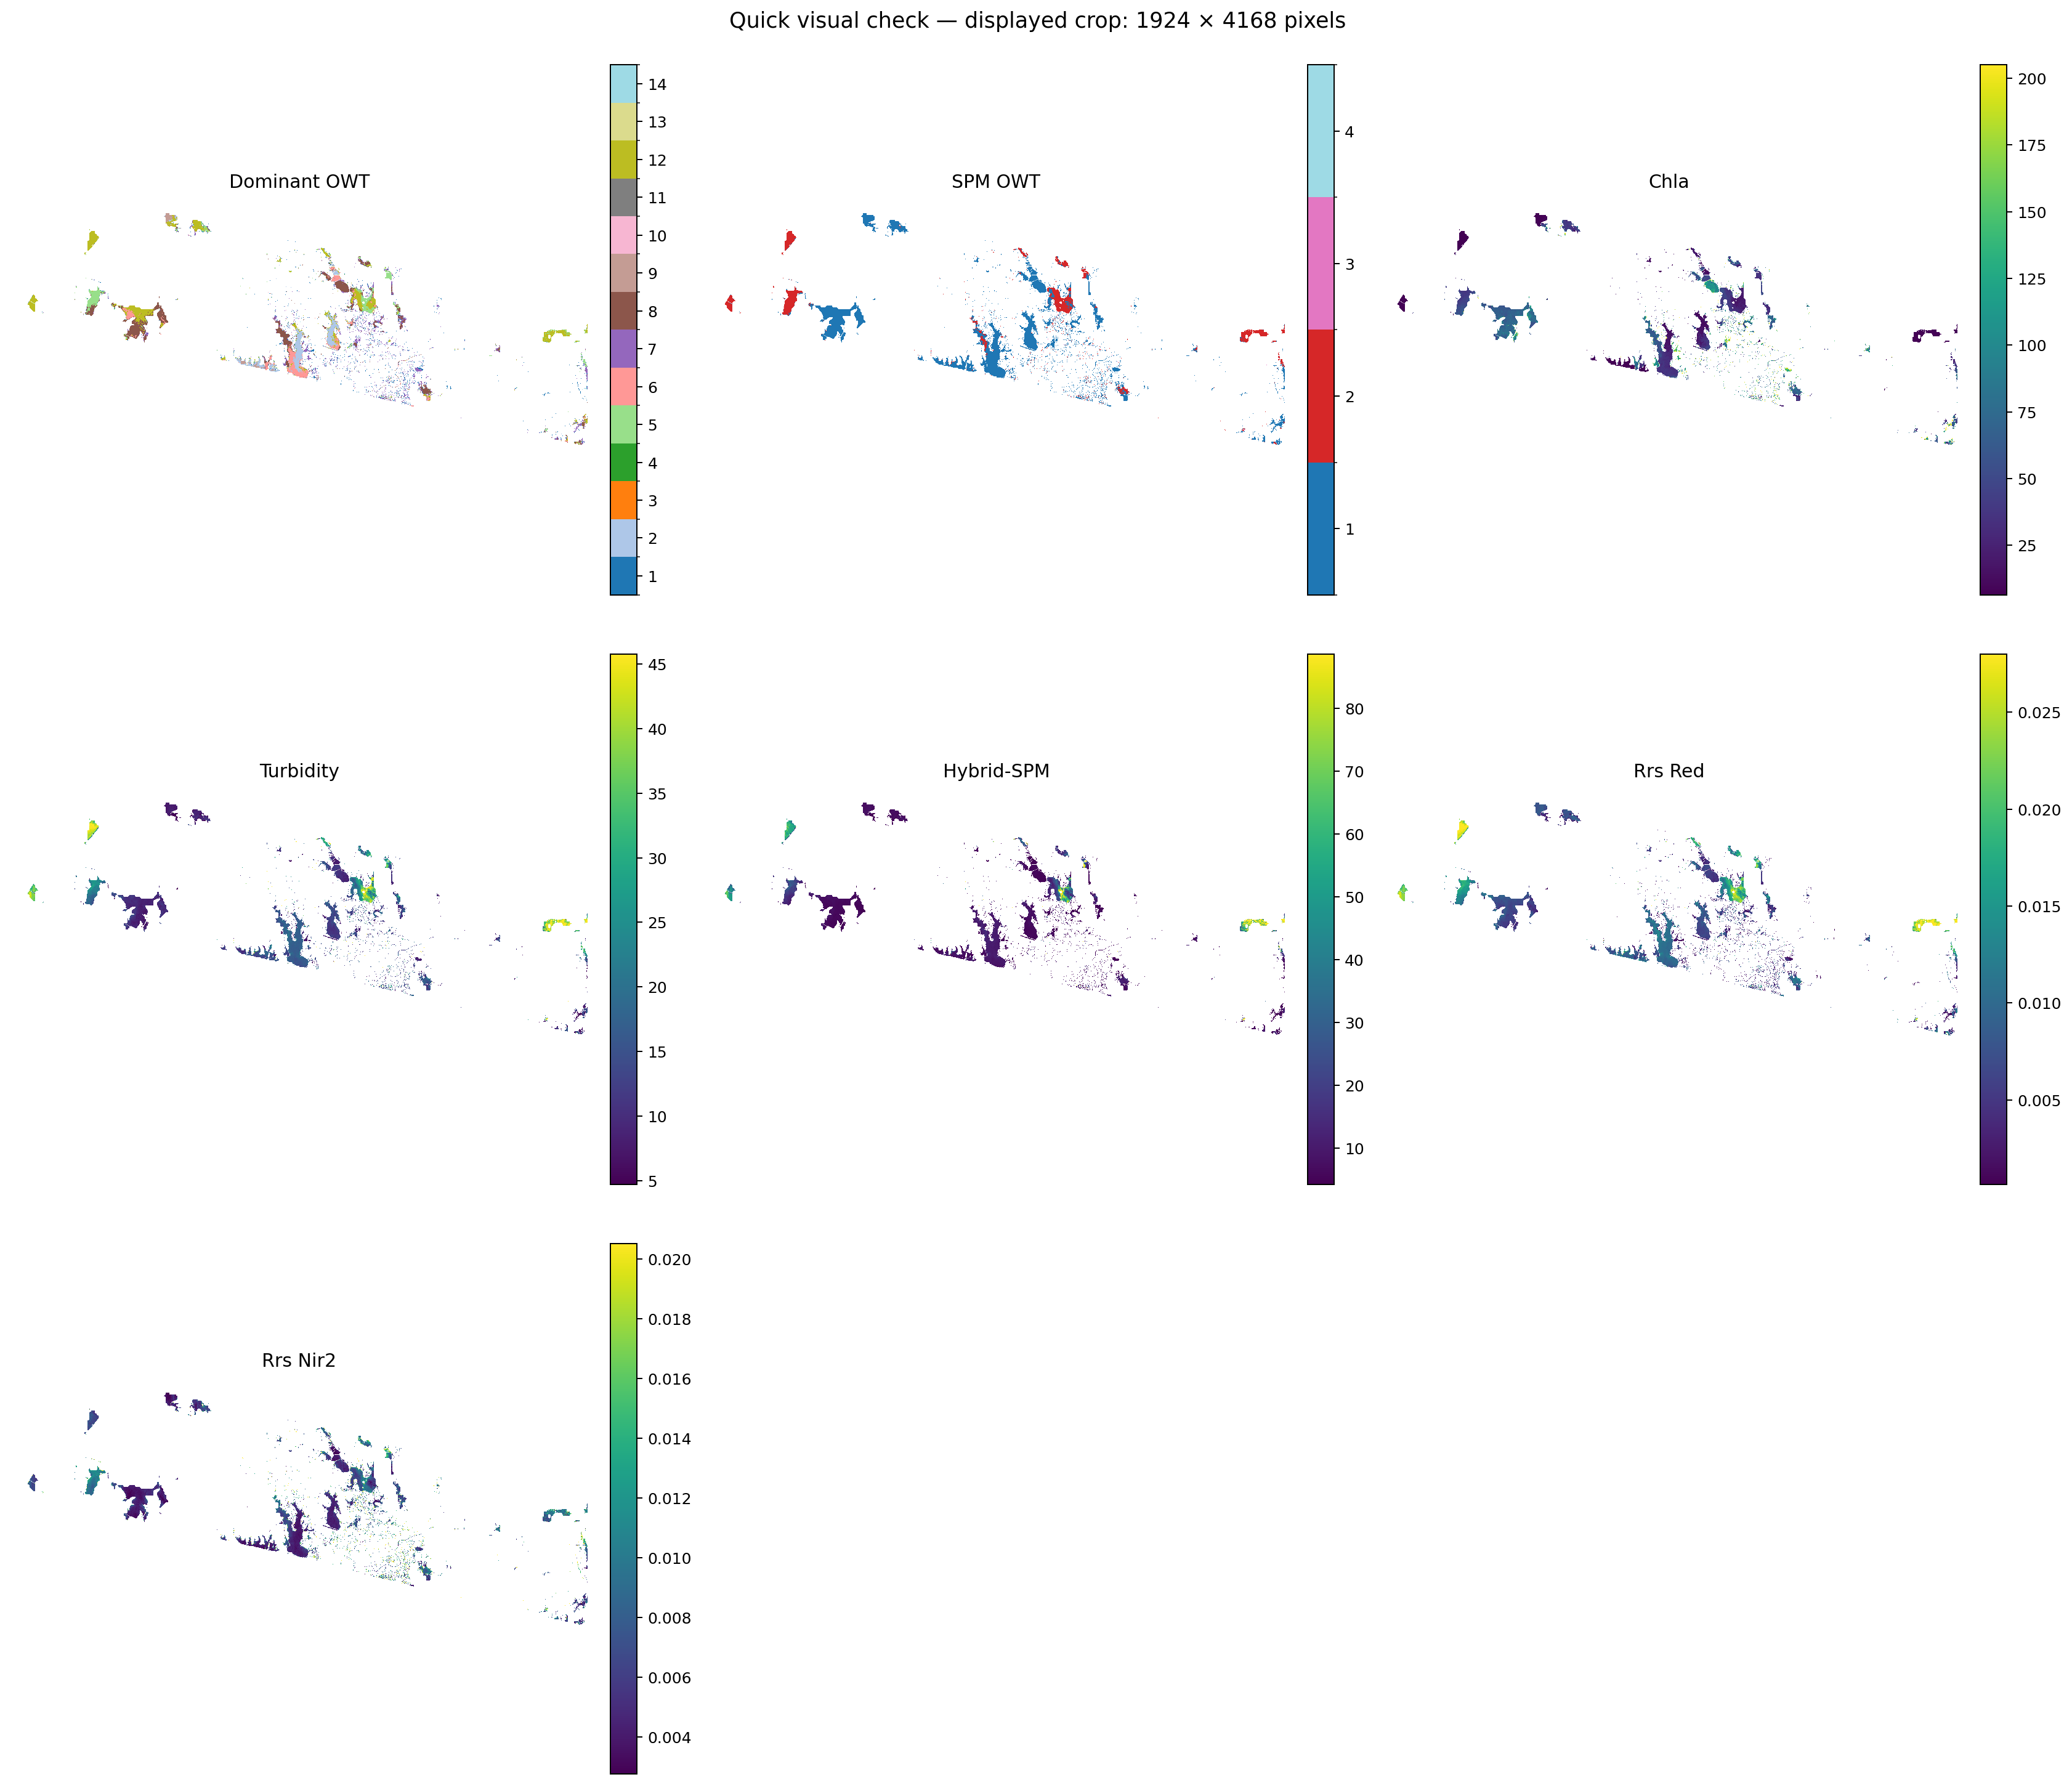

CPU times: user 4.06 s, sys: 1.26 s, total: 5.32 s
Wall time: 5.36 s


In [16]:
%%time
if ZOOM_TO_VALID_DATA:
    row_slice, col_slice = crop_slices_from_items(plot_items, CROP_PADDING_PIXELS)
else:
    sample = as_float_array(plot_items[0][0])
    row_slice, col_slice = slice(0, sample.shape[0]), slice(0, sample.shape[1])

n_panels = len(plot_items)
ncols = min(MAX_COLS, n_panels)
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(PANEL_WIDTH * ncols, PANEL_HEIGHT * nrows),
    dpi=DPI,
    constrained_layout=True,
)

axes = np.atleast_1d(axes).ravel()

for ax, (array, title, kind) in zip(axes, plot_items):
    arr = as_float_array(array)[row_slice, col_slice]

    # Hide NaN/Inf and, optionally, zero background.
    plot_arr = np.ma.masked_invalid(arr)
    if HIDE_ZERO_BACKGROUND:
        plot_arr = np.ma.masked_where(plot_arr == 0, plot_arr)

    cmap_name = "tab20" if kind == "discrete" else "viridis"
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad((1, 1, 1, 0))

    if kind == "discrete":
        values = np.unique(plot_arr.compressed()).astype(int)
        if values.size:
            bounds = np.arange(values.min() - 0.5, values.max() + 1.5, 1)
            norm = BoundaryNorm(bounds, cmap.N)
            im = ax.imshow(plot_arr, interpolation="nearest", resample=False, cmap=cmap, norm=norm)
            ticks = values if values.size <= 16 else None
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=ticks)
        else:
            im = ax.imshow(plot_arr, interpolation="nearest", resample=False, cmap=cmap)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    else:
        values = plot_arr.compressed()
        if values.size:
            vmin, vmax = np.nanpercentile(values, [2, 98])
            if np.isclose(vmin, vmax):
                vmin, vmax = np.nanmin(values), np.nanmax(values)
            im = ax.imshow(
                plot_arr,
                interpolation="nearest",
                resample=False,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )
        else:
            im = ax.imshow(plot_arr, interpolation="nearest", resample=False, cmap=cmap)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_title(title, fontsize=12)
    ax.axis("off")

# Remove unused axes when n_panels is not a perfect grid.
for ax in axes[n_panels:]:
    ax.remove()

crop_height = row_slice.stop - row_slice.start
crop_width = col_slice.stop - col_slice.start
fig.suptitle(
    f"Quick visual check — displayed crop: {crop_height} × {crop_width} pixels",
    fontsize=14,
)

if SAVE_FIGURE:
    fig.savefig(FIGURE_PATH, dpi=250, bbox_inches="tight")
    print(f"Saved figure to: {FIGURE_PATH}")

plt.show()

[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 10. Optional: write GeoTIFF outputs for this one scene

Set `WRITE_OUTPUTS = True` when you want this notebook to write rasters. The output is isolated under `single_scene_example/` inside the configured output folder.

In [17]:
WRITE_OUTPUTS = True
print(f'output folder: {output_folder / tile_id / "single_scene_example"}')

output folder: /media/guimaraes/T7/gpk_test_files/GPK_out/50RKU/single_scene_example


In [18]:
%%time
if WRITE_OUTPUTS:
    scene_output = output_folder / tile_id / "single_scene_example"
    product_dirs = ["npix", "OWT", "OWTSPM", "Chla", "Turb", "HySPM"]
    if report_rrs:
        product_dirs.extend(rrs_bands.keys())

    for product_dir in product_dirs:
        (scene_output / product_dir).mkdir(parents=True, exist_ok=True)

    written = {
        scene_key: {
            "IMG": image_path,
            "WM": water_mask_path,
        }
    }

    npix_file = scene_output / "npix" / f"npixels_{scene_key}.txt"
    np.savetxt(npix_file, pixels, fmt="%s", delimiter=";")
    written[scene_key]["npix"] = str(npix_file)

    no_data = 0
    raster_specs = {
        "OWT": (owt_classes[0, :, :].astype("uint8"), "OWTs", 1),
        "OWTSPM": (classes_turb.astype("uint8"), "OWTSPM", 1),
        "Chla": ((chla * 100).astype("uint16"), "Chla", 0.01),
        "Turb": ((turb * 100).astype("uint16"), "Turb", 0.01),
        "HySPM": ((hyspm * 100).astype("uint16"), "HySPM", 0.01),
    }

    for product, (array, prefix, scale) in raster_specs.items():
        output_tif = scene_output / product / f"{prefix}_{scene_key}.tif"
        Raster.array2tiff(
            ndarray_data=array,
            str_output_file=str(output_tif),
            transform=grs.attrs["trans"],
            projection=grs.attrs["proj"],
            no_data=no_data,
        )
        written[scene_key][product] = str(output_tif)

    if report_rrs:
        for band_name, band_array in rrs_bands.items():
            output_tif = scene_output / band_name / f"{band_name}_{scene_key}.tif"
            Raster.array2tiff(
                ndarray_data=(band_array * 10000).astype("uint16"),
                str_output_file=str(output_tif),
                transform=grs.attrs["trans"],
                projection=grs.attrs["proj"],
                no_data=no_data,
            )
            written[scene_key][band_name] = str(output_tif)

    metadata_json = scene_output / f"{scene_key}_single_scene_outputs.json"
    with open(metadata_json, "w") as fp:
        json.dump(written, fp, indent=2)

    print(f"Wrote outputs to: {scene_output}")
    print(f"Metadata JSON: {metadata_json}")
else:
    print("WRITE_OUTPUTS is False. No files were written.")

<timed exec>:26: RuntimeWarning: invalid value encountered in cast
<timed exec>:27: RuntimeWarning: invalid value encountered in cast


Wrote outputs to: /media/guimaraes/T7/gpk_test_files/GPK_out/50RKU/single_scene_example
Metadata JSON: /media/guimaraes/T7/gpk_test_files/GPK_out/50RKU/single_scene_example/20230628_single_scene_outputs.json
CPU times: user 471 ms, sys: 736 ms, total: 1.21 s
Wall time: 1.21 s


[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  

## 11. Close open datasets

In [19]:
for dataset in [grs, grs_raw]:
    close = getattr(dataset, "close", None)
    if callable(close):
        close()

print("Closed xarray datasets.")

Closed xarray datasets.


[Back to top.](#GET-Pak-workflow-tutorial-to-process-a-single-L2B-image)  